# LCA Workflow Notebook

**READ.ME**

This file helps you calculate and explore LCA results for a set of activities in Brightway 2.5. So far, we have linked a background database with a foreground model in the previous sections of this repository. Here, you can bring the calculations, contribution analysis and graphs together in one workflow which you can adapt for your own projects.

Define the activities once in Step 2 and run the following sections in order. All LCIA results refer to **one reference-product unit** of each selected activity. The final section lets you save the results to Excel together with the graphs and a record of the calculation settings.


## ⚙️ 1. Load Your Project

After ensuring all necessary packages are installed, you call the same project where you have installed and imported your databases. This happens through `bd.projects.set_current(Config.PROJECT_NAME)`.

This section also provides an overview of the available databases. Use `FOREGROUND_NAME` to select your foreground database and `METHODS` to define the impact assessment methods you want to use in the analysis. The example uses the climate change method from the analysis notebook.

You can adjust `CUTOFF` to choose the level of detail in the contribution analysis and `MAX_CONTRIBUTORS` to choose how many contributors are shown in the graphs. `apply_20lca_theme()` sets the default colours and typography for the plots. The `SAVE_OUTPUTS` setting is used in Step 6 and is currently set to `True`.


In [1]:
from pathlib import Path
import sys
import json
from datetime import datetime, timezone
from importlib.metadata import version

import bw2data as bd
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display
from functions.utils import Config
from functions.fun_visualisation import apply_20lca_theme
from functions.fun_workflow import (
    multi_category_score_table,
    calculate_contributions,
    combine_contributions,
    check_contribution_scores,
    plot_workflow_contributions,
)


In [2]:
# define a project where we install the databases and work in this script
bd.projects.set_current(Config.PROJECT_NAME)

In [3]:
bd.databases

Databases dictionary with 7 object(s):
	BONSAI v2.4.1
	BONSAI v2.4.1 biosphere
	bafu-2026
	biosphere3
	brightway_project_template
	ecoinvent-3.12-biosphere
	ecoinvent-3.12-consequential

In [4]:
# Defaults match the analysis notebook; edit these for another project.
FOREGROUND_NAME = "brightway_project_template"
METHODS = {
    "Climate change": (
        "ecoinvent-3.12", "EF v3.1", "climate change",
        "global warming potential (GWP100)",
    ),
}
CUTOFF = 0.005
MAX_CONTRIBUTORS = 15
SAVE_OUTPUTS = True

if FOREGROUND_NAME not in bd.databases:
    raise ValueError(f"Database is not registered: {FOREGROUND_NAME}")
if not METHODS:
    raise ValueError("Select at least one impact assessment method.")
for label, method in METHODS.items():
    if method not in bd.methods:
        raise ValueError(f"Method is not registered: {label}: {method}")

foreground = bd.Database(FOREGROUND_NAME)
CATEGORIES = {
    label: {
        "label": label,
        "unit": bd.Method(method).metadata.get("unit", "LCIA units"),
        "methods": [method],
    }
    for label, method in METHODS.items()
}


In [5]:
# Set the default plotting theme.
apply_20lca_theme()


## 🔍 2. Select the Activities to Analyse

This section shows the activities available in your foreground database, including their names, locations, units and codes. You can use this overview to find the processes you want to analyse. Activity codes help you select an exact entry where several processes have the same name.

The example below selects two random activities from the ecoinvent database and stores them in `ACTIVITIES`. You can replace these entries with your own processes and give each one a label to use throughout the workflow. Running the random selection again may select different activities.

The `activity_selection` table provides an overview of the selected processes and their reference products. Each calculation uses one unit of the selected product; comparisons between products need to be based on equivalent services.


In [6]:
available_activities = pd.DataFrame([
    {
        "code": act["code"], "name": act["name"],
        "location": act.get("location"), "unit": act.get("unit"),
    }
    for act in foreground
])
display(available_activities)


,code,name,location,unit
0,18cf9c1477062c6c32dd5fb61d8a3a06,production of porcelain ceramics,RER,kilogram


In [7]:
ecoinvent = bd.Database(Config.ECOINVENT_CLCA_NAME)

In [8]:
random1 = ecoinvent.random()
random2 = ecoinvent.random()

ACTIVITIES = {
    "random1": random1,
    "random2": random2,
}

if not ACTIVITIES:
    raise ValueError("Select at least one activity.")

activity_selection = pd.DataFrame([
    {
        "label": label, "database": act.key[0], "code": act.key[1],
        "name": act["name"], "location": act.get("location"),
        "reference_product": act.get("reference product"),
        "amount": 1, "unit": act["unit"],
    }
    for label, act in ACTIVITIES.items()
])
display(activity_selection)


,label,database,code,name,location,reference_product,amount,unit
0,random1,ecoinvent-3.12-consequential,c5cf3f94e64281f72d42721ad9dbb845,"market for hydrogen, gaseous, low pressure",US,"hydrogen, gaseous, low pressure",1,kilogram
1,random2,ecoinvent-3.12-consequential,03078d8ac1036d8a22fddf4cf1058fb7,"market for transport, passenger, aircraft, sho...",GLO,"transport, passenger, aircraft, short haul",1,person kilometer


## 📈 3. LCIA Overview

This section shows how LCA results can be calculated for all selected activities and impact assessment methods in one step. `multi_category_score_table()` returns one score for each activity and impact category.

The overview table displays the impact categories in separate columns. The results are also stored in `scores` as one row per activity and category, which you can use for further analysis.


In [9]:
scores = multi_category_score_table(ACTIVITIES, CATEGORIES)
scores_wide = scores.pivot(
    index=["Process", "Activity Name", "Functional Unit"],
    columns="Category", values="Score",
).reset_index()
display(scores_wide)


c:\Users\TimWeber\repos_20LCA\brightway_project_template\.venv\Lib\site-packages\bw2calc\__init__.py:59: UserWarning: No fast sparse solver found
  warnings.warn("No fast sparse solver found")


Category,Process,Activity Name,Functional Unit,Climate change (kg CO2-Eq)
0,random1,"market for hydrogen, gaseous, low pressure",kilogram,10.966531
1,random2,"market for transport, passenger, aircraft, sho...",person kilometer,0.135233


## 📊 4. Contribution Analysis

This section shows which inputs contribute to the LCA score of each selected activity. `calculate_contributions()` calculates the first level of inputs, including their upstream impacts. You can adjust `CUTOFF` in Step 1 based on the level of detail you want from the analysis.

Each table includes the total score, the input contributions and the direct biosphere impacts. Inputs below the cutoff are grouped in an other row. The inputs, direct impacts and other row together make up the total; the total row should not be added to these contributions again.

The cutoff is relative to the absolute net score. Where negative credits nearly cancel positive impacts, the contribution fractions can become large. Fractions are undefined when the total score is zero.

The individual tables are stored in `contribution_tables`, while `contributions` brings them together for further analysis and export. The final check compares the total from each contribution table with the LCA score calculated in Step 3.


In [10]:
contribution_tables = calculate_contributions(
    ACTIVITIES, CATEGORIES, cutoff=CUTOFF,
)
contributions = combine_contributions(
    contribution_tables, ACTIVITIES, CATEGORIES,
)

for (label, category), table in contribution_tables.items():
    print(f"{label} | {category}")
    display(table[["label", "score", "fraction", "amount", "name"]])

score_checks = check_contribution_scores(
    scores, contribution_tables, CATEGORIES,
)
display(score_checks)
if not score_checks["Matches"].all():
    raise ValueError("Contribution roots differ from the calculated LCA scores.")


random1 | Climate change


,label,score,fraction,amount,name
0,root,10.966531,1.000000,1.000000,"market for hydrogen, gaseous, low pressure"
1,input_0,0.990340,0.090306,0.053886,"hydrogen production, coal gasification"
2,input_1,9.574563,0.873071,0.900849,"hydrogen production, steam methane reforming"
3,input_2,0.220212,0.020080,0.022633,"carbon monoxide production, from synthesis gas..."
4,input_3,0.181415,0.016543,0.022633,"carbon monoxide production, from synthesis gas..."
5,other,0.000000,0.000000,NaN,other


random2 | Climate change


,label,score,fraction,amount,name
0,root,0.135233,1.0,1.0,"market for transport, passenger, aircraft, sho..."
1,input_0,0.135233,1.0,1.0,"transport, passenger, aircraft, short haul"
2,other,0.000000,0.0,NaN,other


,Process,Category,Score,Recursive root,Matches
0,random1,Climate change,10.966531,10.966531,True
1,random2,Climate change,0.135233,0.135233,True


## 🎨 5. Plot Contribution Analysis Graphs

This section shows how to display the contribution results as graphs using the default 2-0 colours and typography. `plot_workflow_contributions()` creates a graph for each selected activity and impact category from the tables calculated above.

You can adjust `MAX_CONTRIBUTORS` in Step 1 to choose how many contributors are displayed. Contributions are ranked by absolute magnitude, so negative credits can also be shown. This setting only changes the graphs; the contribution tables remain available for further analysis.


In [11]:
import importlib
import functions.fun_workflow as workflow

importlib.reload(workflow)
from functions.fun_workflow import plot_workflow_contributions

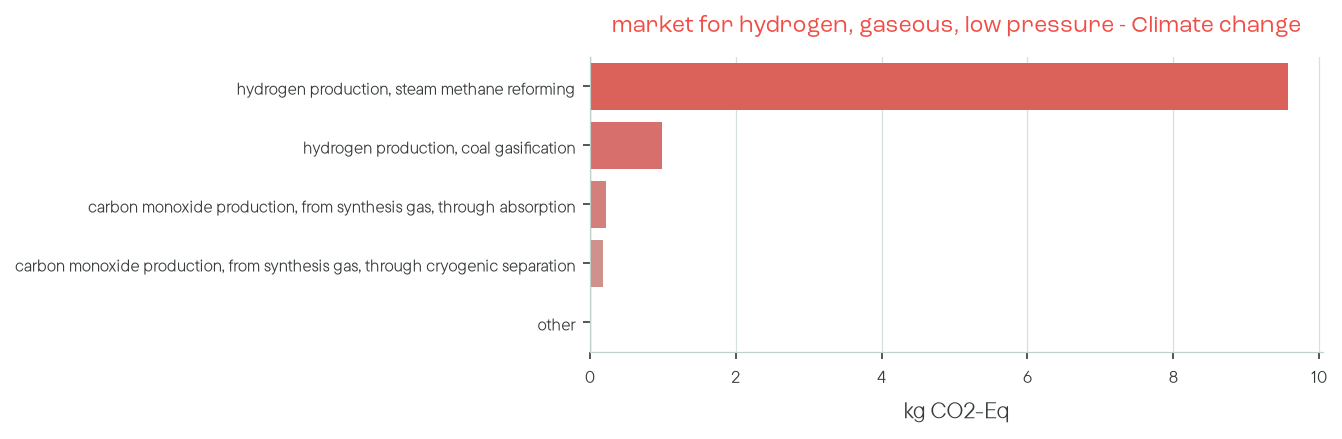

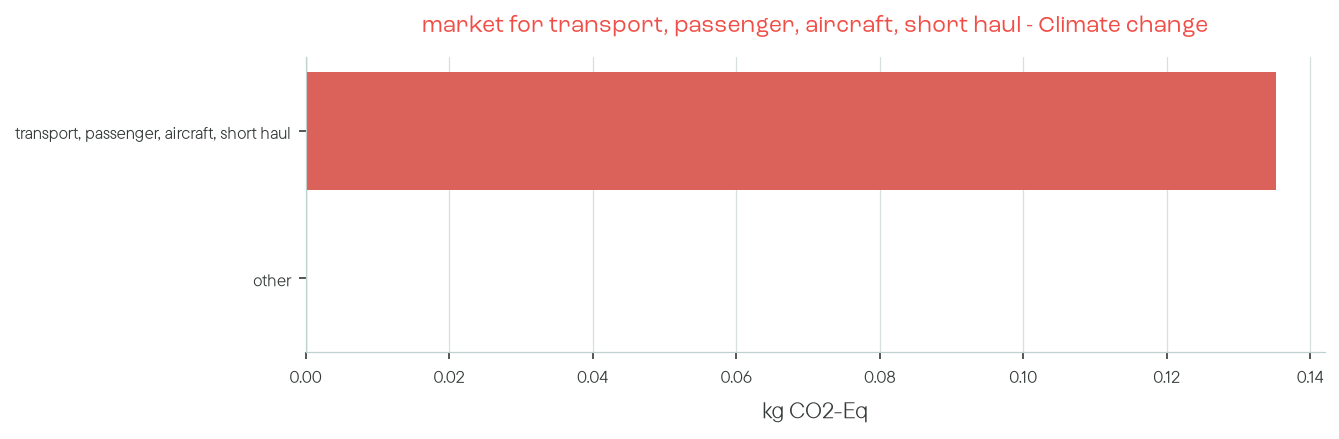

In [12]:
figures = plot_workflow_contributions(
    contribution_tables, ACTIVITIES, CATEGORIES, top_n=MAX_CONTRIBUTORS,
)
for figure in figures.values():
    display(figure)
    plt.close(figure)


## 🗂️ 6. Save the Results (Optional)

You can export the LCA results to Excel and save the contribution graphs as PNG files through the following cell. `SAVE_OUTPUTS` is currently set to `True` in Step 1. Set it to `False` and rerun the settings cell if you want to keep the results in memory without saving them.

The files are saved in a timestamped folder under `Config.PROJECT_EXPORTS_PATH`. `LCA_results.xlsx` contains the selected activity information, LCA scores, contribution tables, score checks and a separate Life Cycle Inventory sheet in a formatted workbook. The total is labelled separately from its contributions and should not be added to them again.

The folder also contains the graphs and `run_record.json`, which records the selected activities, methods and calculation settings. The Life Cycle Inventory sheet contains a table for each process selected in Step 2, with Exchange, Unit, Amount and Comments columns grouped into technosphere and biosphere exchanges. Production exchanges show the stored reference basis. Inventory amounts and signs are exported as stored, without normalization, cutoff or upstream aggregation; exchange comments are preserved.


In [13]:
if SAVE_OUTPUTS:
    run_id = datetime.now(timezone.utc).strftime("%Y%m%dT%H%M%S_%fZ")
    output_dir = Config.PROJECT_EXPORTS_PATH / f"workflow_{run_id}"    
    output_dir.mkdir(parents=True, exist_ok=False)
    from functions.fun_export import export_workflow_excel

    export_workflow_excel(
        output_dir / "LCA_results.xlsx",
        activity_selection=activity_selection,
        activities=ACTIVITIES,
        scores=scores,
        scores_wide=scores_wide,
        contributions=contributions,
        score_checks=score_checks,
    )

    figure_order = []
    for number, ((label, category), figure) in enumerate(figures.items(), start=1):
        filename = f"contribution_{number:02d}.png"
        figure.savefig(output_dir / filename, dpi=300, bbox_inches="tight")
        figure_order.append({
            "file": filename, "activity": label, "category": category,
        })

    record = {
        "run_id": run_id, "project": str(bd.projects.current),
        "foreground": FOREGROUND_NAME,
        "activities": activity_selection.to_dict(orient="records"),
        "methods": METHODS, "cutoff": CUTOFF, "max_level": 1, "top_n": MAX_CONTRIBUTORS,
        "versions": {
            package: version(package)
            for package in [
                "bw2data", "bw2calc", "bw2analyzer",
                "pandas", "numpy", "matplotlib", "seaborn",
            ]
        },
        "figures": figure_order,
    }
    (output_dir / "run_record.json").write_text(
        json.dumps(record, indent=2), encoding="utf-8",
    )
    print("Saved to:", output_dir)


Saved to: C:\Users\TimWeber\OneDrive - 2.-0 LCA Consultants ApS\Intranet - Internal Development Projects\Brightway Open_MA\data4workshops\excel_model_example\exports\workflow_20260929T080023_348825Z
